<a id="setup"></a>
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

raw = pd.read_excel('EDA data/CBDI3_All_Evals_for_NSS.xlsx')
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head(3)


Rows: 23,947   Columns: 220


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:

domains = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive']

subdomains = {
    'Adaptive': ['Adaptive-Self Care', 'Adaptive-Personal Responsibility'],
    'Social-Emotional': ['Social Emotional-Adult Interaction', 'Social Emotional-Peer Interaction',
                         'Social Emotional-Self Concept / Social Role'],
    'Communication': ['Communication-Receptive Communication', 'Communication-Expressive Communication'],
    'Motor': ['Motor-Gross Motor', 'Motor-Fine Motor', 'Motor-Perceptual Motor'],
    'Cognitive': ['Cognitive-Attention and Memory', 'Cognitive-Reasoning / Academic Skills',
                  'Cognitive-Perception and Concepts']
}

domain_dq_cols = {d: f'{d} Developmental Quotient' for d in domains}
domain_dq_cols['Total'] = 'BDI-3 Total Developmental Quotient'

print("Domains and sub-domains defined.")


Domains and sub-domains defined.


In [3]:
df = raw.copy()


n_before = len(df)
df = df.drop_duplicates()
print(f"Dropped {n_before - len(df):,} exact duplicate rows -> {len(df):,} rows remain")


Dropped 4,447 exact duplicate rows -> 19,500 rows remain


In [4]:
df['Missing_ID'] = df['Child ID'].astype(str).str.startswith('SP')
print(f"Records with a system-generated SP## ID (no real Child ID): {df['Missing_ID'].sum():,} "
      f"({df['Missing_ID'].mean()*100:.1f}% of records)")


Records with a system-generated SP## ID (no real Child ID): 3,291 (16.9% of records)


In [5]:
rdi_cols = [c for c in df.columns if c.endswith('RDI')]

def fix_rdi(v):
    if pd.isna(v):
        return None
    if isinstance(v, (datetime.datetime, pd.Timestamp)):
        return f'{v.month}/90'
    return str(v).strip()

for c in rdi_cols:
    df[c] = df[c].apply(fix_rdi)

print("Example after fix:")
df[['Adaptive RDI']].head(10)


Example after fix:


,Adaptive RDI
0,39/90
1,79/90
2,77/90
3,99/90
4,9/90
5,79/90
6,71/90
7,96/90
8,21/90
9,91/90


In [6]:
dot_cols = [c for c in df.columns if 'Date of Testing' in c]
df['Eval Date'] = df[dot_cols].bfill(axis=1).iloc[:, 0]

df['Age at Eval (months)'] = (df['Eval Date'] - df['Date of Birth']).dt.days / 30.4375

df['Age at Eval (months)'].describe()


count    19498.000000
mean        22.067663
std         10.722195
min          0.000000
25%         14.850103
50%         23.819302
75%         30.685832
max         48.295688
Name: Age at Eval (months), dtype: float64

In [7]:
region_map = {
    'East Tennessee': 'Region A (East TN / First TN / Southeast)',
    'First Tennessee': 'Region A (East TN / First TN / Southeast)',
    'Southeast Tennessee': 'Region A (East TN / First TN / Southeast)',
    'Greater Nashville': 'Region B (Nashville / Upper Cumberland / South Central)',
    'Upper Cumberland': 'Region B (Nashville / Upper Cumberland / South Central)',
    'South Central': 'Region B (Nashville / Upper Cumberland / South Central)',
    'Northwest': 'Region C (Northwest / Southwest / Memphis Delta)',
    'Southwest': 'Region C (Northwest / Southwest / Memphis Delta)',
    'Memphis Delta': 'Region C (Northwest / Southwest / Memphis Delta)',
}
df['Region'] = df['Location - Sub Level 1'].map(region_map)


pd.crosstab(df['Region'], df['contract number'])


contract number,contract 1,contract 2,contract 3
Region,,,
Region A (East TN / First TN / Southeast),6624,0,0
Region B (Nashville / Upper Cumberland / South Central),0,8017,0
Region C (Northwest / Southwest / Memphis Delta),0,0,4772


In [8]:
examiner_cols = [c for c in df.columns if c.endswith('Examiner')]
df['Evaluator'] = df[examiner_cols].bfill(axis=1).iloc[:, 0]
print(f"Number of unique evaluators: {df['Evaluator'].nunique()}")


Number of unique evaluators: 105


C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\3952074839.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Evaluator'] = df[examiner_cols].bfill(axis=1).iloc[:, 0]


In [9]:
empty_cols = [f'Code {i}' for i in range(1, 11)]
df = df.drop(columns=[c for c in empty_cols if c in df.columns])

print(f"Cleaned dataset shape: {df.shape}")
df[['Child ID','Missing_ID','Gender','Region','Program Label','Evaluator','Age at Eval (months)']].head()


Cleaned dataset shape: (19500, 215)


,Child ID,Missing_ID,Gender,Region,Program Label,Evaluator,Age at Eval (months)
0,44879,False,F,Region C (Northwest / Southwest / Memphis Delta),BDI-3 Eligibility Evaluation,Kelly Bryan,8.837782
1,47795,False,F,Region B (Nashville / Upper Cumberland / South...,BDI-3 Eligibility Evaluation,Patti Lyle,26.874743
2,54340,False,M,Region A (East TN / First TN / Southeast),BDI-3 Eligibility Evaluation,Karen McMillion,21.453799
3,54344,False,F,Region A (East TN / First TN / Southeast),BDI-3 Eligibility Evaluation,Jennifer Vines,11.597536
4,54515,False,M,Region C (Northwest / Southwest / Memphis Delta),BDI-3 Eligibility Evaluation,Ally Simmons,15.671458


<a id="q1"></a>
## 3. Q1 — In which domains (and sub-domains) are children performing highest and lowest?

We use the **Developmental Quotient (DQ)** for domains (mean = 100 in the norm sample) and the **Scaled Score (SS)** for sub-domains (mean = 10 in the norm sample) since these are the norm-referenced scores the BDI-3 manual centers the analysis on.

In [10]:
domain_dq = df[list(domain_dq_cols.values())].rename(columns={v:k for k,v in domain_dq_cols.items()})
domain_summary = domain_dq.describe().T[['mean','std','min','max']].sort_values('mean')
domain_summary


,mean,std,min,max
Communication,79.604499,20.168400,46.0,154.0
Adaptive,87.435079,17.438731,46.0,148.0
Total,87.687600,16.866901,40.0,160.0
Cognitive,89.061804,16.498114,40.0,160.0
Social-Emotional,94.470051,16.695712,46.0,154.0
Motor,94.511222,17.288802,42.0,154.0


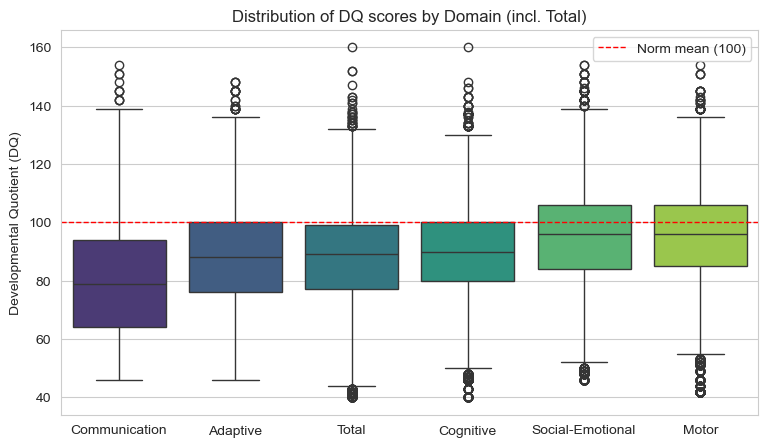

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
order = domain_summary.index
sns.boxplot(data=domain_dq[order], ax=ax, palette='viridis')
ax.axhline(100, color='red', linestyle='--', linewidth=1, label='Norm mean (100)')
ax.set_ylabel('Developmental Quotient (DQ)')
ax.set_title('Distribution of DQ scores by Domain (incl. Total)')
ax.legend()
plt.show()


In [12]:
ss_cols = {c.replace(' SS',''): c for c in df.columns if c.endswith(' SS')}
sub_summary = df[list(ss_cols.values())].rename(columns={v:k for k,v in ss_cols.items()}).describe().T[['mean','std','min','max']].sort_values('mean')
sub_summary


,mean,std,min,max
Communication-Expressive Communication,6.493991,3.672590,1.0,19.0
Communication-Receptive Communication,6.709110,3.622658,1.0,19.0
Adaptive-Self Care,7.453832,3.144153,1.0,19.0
Cognitive-Perception and Concepts,7.785443,3.259881,1.0,19.0
Social Emotional-Peer Interaction,7.834124,3.298726,1.0,19.0
Adaptive-Personal Responsibility,7.957826,3.861019,1.0,19.0
Social Emotional-Self Concept / Social Role,8.032793,3.298105,1.0,19.0
Cognitive-Reasoning / Academic Skills,8.097803,3.203242,1.0,19.0
Cognitive-Attention and Memory,8.407206,2.714675,1.0,19.0
Motor-Perceptual Motor,8.545417,3.924365,1.0,19.0


C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\2338003543.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


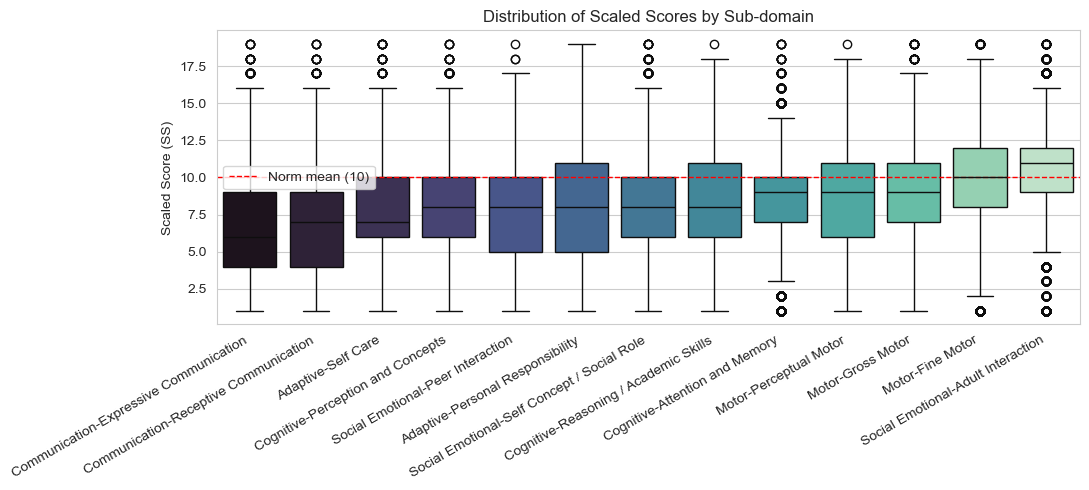

In [13]:
fig, ax = plt.subplots(figsize=(11,5))
sub_df = df[list(ss_cols.values())].rename(columns={v:k for k,v in ss_cols.items()})
order = sub_summary.index
sns.boxplot(data=sub_df[order], ax=ax, palette='mako')
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='Norm mean (10)')
ax.set_ylabel('Scaled Score (SS)')
ax.set_title('Distribution of Scaled Scores by Sub-domain')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Q2 — Do children perform similarly across all domains, or are there differences from domain to domain?


Children with a first eligibility evaluation: 12,110


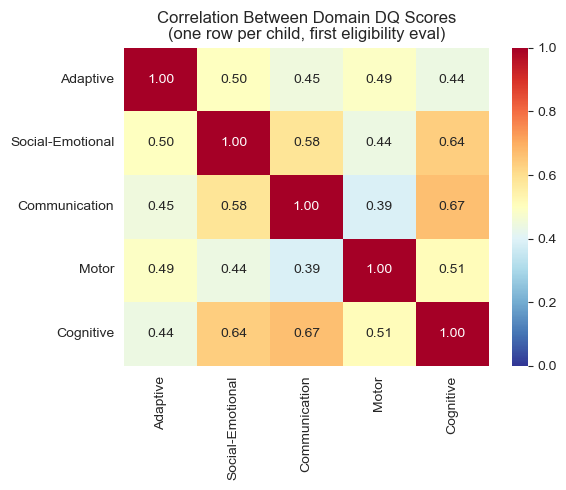

In [14]:
elig = df[df['Program Label'] == 'BDI-3 Eligibility Evaluation'].sort_values('Eval Date')
first_elig = elig.drop_duplicates(subset='Child ID', keep='first')
print(f"Children with a first eligibility evaluation: {len(first_elig):,}")

corr = first_elig[list(domain_dq_cols.values())[:-1]].rename(columns={v:k for k,v in domain_dq_cols.items()}).corr()

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation Between Domain DQ Scores\n(one row per child, first eligibility eval)')
plt.tight_layout()
plt.show()


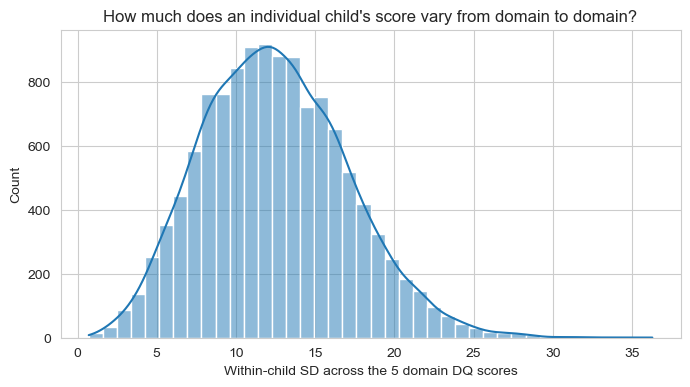

count    12107.000000
mean        12.483438
std          4.585616
min          0.707107
25%          9.126883
50%         12.218838
75%         15.514509
max         36.286361
dtype: float64

In [15]:
domain_only = first_elig[list(domain_dq_cols.values())[:-1]].rename(columns={v:k for k,v in domain_dq_cols.items()})
per_child_std = domain_only.std(axis=1)

fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(per_child_std.dropna(), bins=40, kde=True, ax=ax)
ax.set_xlabel('Within-child SD across the 5 domain DQ scores')
ax.set_title('How much does an individual child\'s score vary from domain to domain?')
plt.show()

per_child_std.describe()


## 5. Q3 — Is there a pattern of significant sub-domain gaps within a domain? (e.g. Expressive vs. Receptive Communication)



In [16]:
pairs = []
for dom, subs in subdomains.items():
    for i in range(len(subs)):
        for j in range(i + 1, len(subs)):
            pairs.append((dom, subs[i], subs[j]))

gap_rows = []
for dom, sub_a, sub_b in pairs:
    col_a, col_b = ss_cols[sub_a], ss_cols[sub_b]
    paired = df[[col_a, col_b]].dropna()
    diff = paired[col_a] - paired[col_b]
    gap_rows.append({
        'Domain': dom,
        'Sub-domain A': sub_a,
        'Sub-domain B': sub_b,
        'Mean A': paired[col_a].mean(),
        'Mean B': paired[col_b].mean(),
        'Mean Gap (A-B)': diff.mean(),
        'Gap Std Dev': diff.std(),
        'n': len(paired)
    })

gap_df = pd.DataFrame(gap_rows).sort_values('Mean Gap (A-B)', key=abs, ascending=False)
gap_df


,Domain,Sub-domain A,Sub-domain B,Mean A,Mean B,Mean Gap (A-B),Gap Std Dev,n
1,Social-Emotional,Social Emotional-Adult Interaction,Social Emotional-Peer Interaction,10.400784,7.834589,2.566195,2.530317,9691
2,Social-Emotional,Social Emotional-Adult Interaction,Social Emotional-Self Concept / Social Role,10.452091,8.032640,2.419451,2.759382,19485
10,Cognitive,Cognitive-Reasoning / Academic Skills,Cognitive-Perception and Concepts,8.097803,6.741876,1.355927,2.630382,9693
0,Adaptive,Adaptive-Self Care,Adaptive-Personal Responsibility,6.770548,7.958131,-1.187584,3.249933,9697
5,Motor,Motor-Gross Motor,Motor-Fine Motor,8.621400,9.782923,-1.161524,3.115592,19477
7,Motor,Motor-Fine Motor,Motor-Perceptual Motor,9.431462,8.545417,0.886045,3.097570,9688
9,Cognitive,Cognitive-Attention and Memory,Cognitive-Perception and Concepts,8.406550,7.785227,0.621323,2.746638,19481
3,Social-Emotional,Social Emotional-Peer Interaction,Social Emotional-Self Concept / Social Role,7.834245,7.249665,0.584580,2.761825,9689
8,Cognitive,Cognitive-Attention and Memory,Cognitive-Reasoning / Academic Skills,7.764263,8.097803,-0.333540,2.473564,9693
4,Communication,Communication-Receptive Communication,Communication-Expressive Communication,6.707278,6.494222,0.213057,2.831823,19469


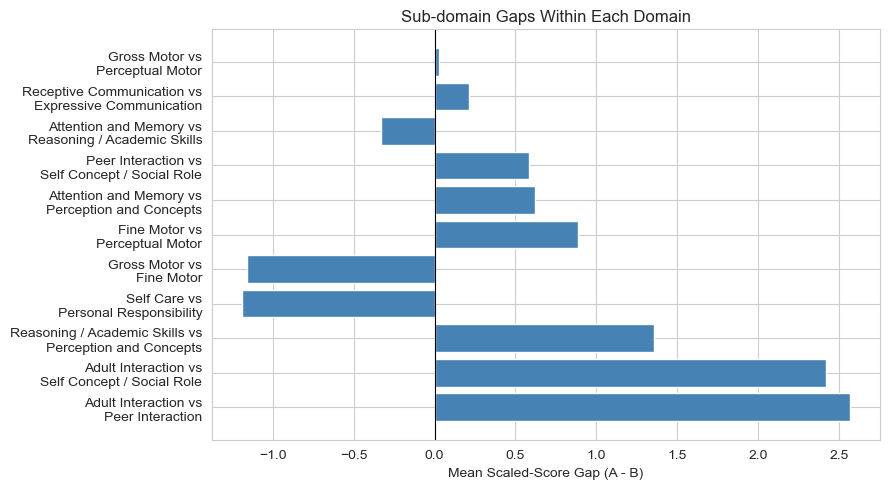

In [17]:
fig, ax = plt.subplots(figsize=(9,5))
labels = gap_df['Sub-domain A'].str.split('-').str[-1] + ' vs\n' + gap_df['Sub-domain B'].str.split('-').str[-1]
ax.barh(labels, gap_df['Mean Gap (A-B)'], color='steelblue')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Scaled-Score Gap (A - B)')
ax.set_title('Sub-domain Gaps Within Each Domain')
plt.tight_layout()
plt.show()


<a id="q4"></a>
## 6. Q4 — Does the child's age impact their scoring?

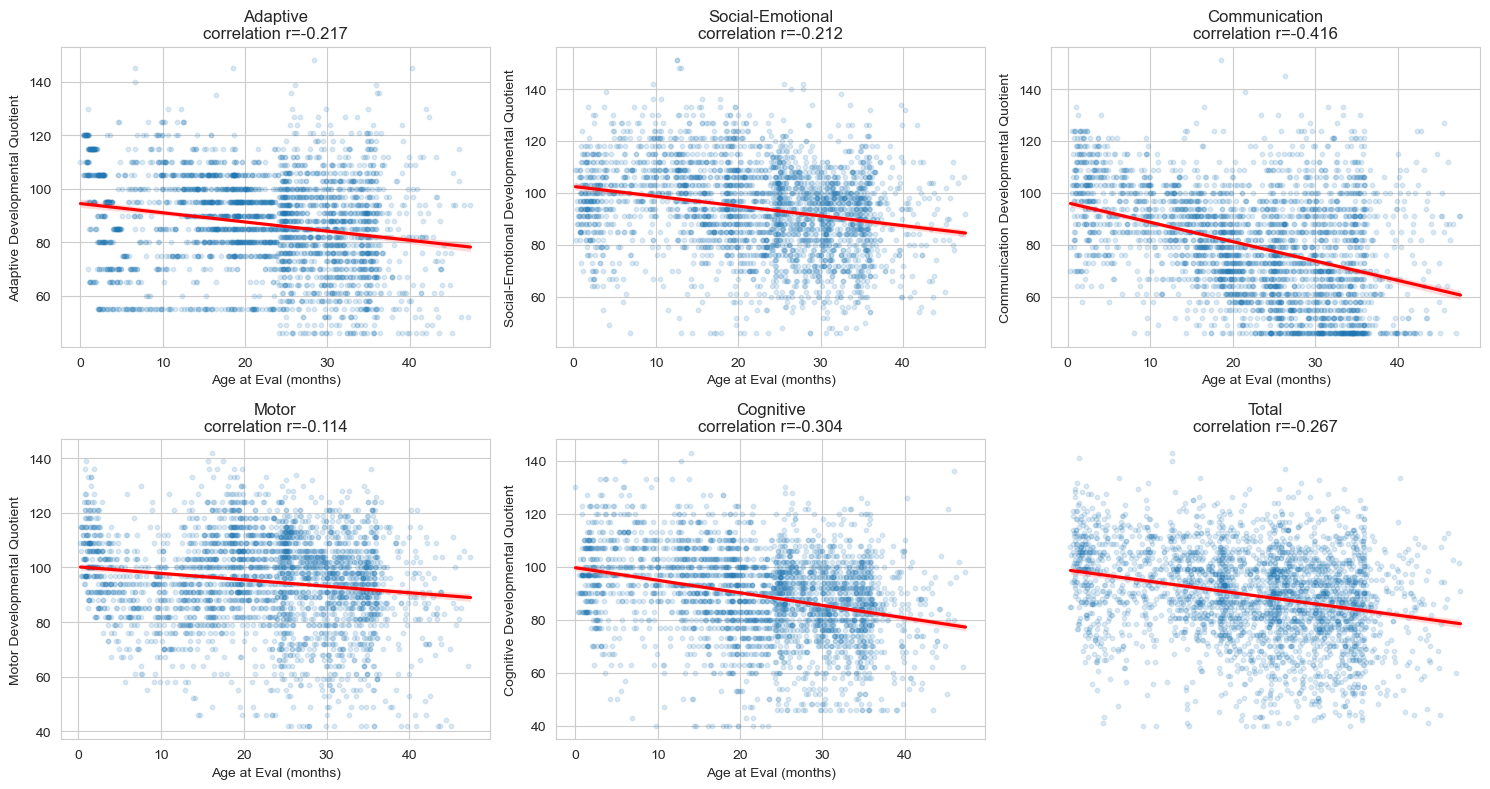

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = list(domain_dq_cols.items())
for ax, (name, col) in zip(axes.flat, plot_cols):
    sample = df[['Age at Eval (months)', col]].dropna().sample(min(3000, df[col].notna().sum()), random_state=1)
    sns.regplot(data=sample, x='Age at Eval (months)', y=col, ax=ax,
                scatter_kws={'alpha':0.15, 's':10}, line_kws={'color':'red'})
    r = df[['Age at Eval (months)', col]].dropna().corr().iloc[0,1]
    ax.set_title(f'{name}\ncorrelation r={r:.3f}')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


In [19]:
age_corr_rows = []
for name, col in domain_dq_cols.items():
    r = df[['Age at Eval (months)', col]].dropna().corr().iloc[0,1]
    age_corr_rows.append({'Domain': name, 'Correlation (age vs DQ)': r})
pd.DataFrame(age_corr_rows)


,Domain,Correlation (age vs DQ)
0,Adaptive,-0.217298
1,Social-Emotional,-0.211942
2,Communication,-0.415583
3,Motor,-0.114180
4,Cognitive,-0.303887
5,Total,-0.267443


## 7. Q5 — If eligibility could also be based on the BDI-3 Total DQ (≤70), would any additional children qualify?



In [20]:
dq_domain_cols = [domain_dq_cols[d] for d in domains]

def current_eligibility(row):
    scores = row[dq_domain_cols].dropna()
    if (scores <= 70).any():
        return True
    if ((scores >= 71) & (scores <= 78)).sum() >= 2:
        return True
    return False

elig_df = df[df['Program Label'] == 'BDI-3 Eligibility Evaluation'].copy()
elig_df['Eligible_Current'] = elig_df.apply(current_eligibility, axis=1)
elig_df['Eligible_TotalDQ'] = elig_df['BDI-3 Total Developmental Quotient'] <= 70

newly_eligible = elig_df[(~elig_df['Eligible_Current']) & (elig_df['Eligible_TotalDQ'])]

print(f"Eligibility evaluations analyzed: {len(elig_df):,}")
print(f"Currently eligible (domain-based rule): {elig_df['Eligible_Current'].sum():,}")
print(f"Would be eligible under Total DQ <= 70: {elig_df['Eligible_TotalDQ'].sum():,}")
print(f"Children eligible under Total DQ rule but NOT under current rule: {len(newly_eligible):,}")


Eligibility evaluations analyzed: 12,392
Currently eligible (domain-based rule): 5,812
Would be eligible under Total DQ <= 70: 1,452
Children eligible under Total DQ rule but NOT under current rule: 0


In [21]:
newly_eligible[['Child ID','Region','BDI-3 Total Developmental Quotient'] + dq_domain_cols].head(20)


,Child ID,Region,BDI-3 Total Developmental Quotient,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient


<a id="q6"></a>
## 8. Q6 — Is there a difference in scoring based on evaluation type?

In [22]:
prog_summary = df.groupby('Program Label')[dq_domain_cols + ['BDI-3 Total Developmental Quotient']].agg(['mean','std','count'])
prog_summary


Adaptive Developmental Quotient             \
                                                              mean        std   
Program Label                                                                   
BDI-3 Annual Evaluation                                  84.352984  18.633114   
BDI-3 Eligibility Evaluation                             89.183029  16.448901   
BDI-3 Milestone or Exit Evaluation                       85.605911  19.391290   

                                           \
                                    count   
Program Label                               
BDI-3 Annual Evaluation              6904   
BDI-3 Eligibility Evaluation        12386   
BDI-3 Milestone or Exit Evaluation    203   

                                   Social-Emotional Developmental Quotient  \
                                                                      mean   
Program Label                                                                
BDI-3 Annual Evaluation                                          92.786978   
BDI-3 Eligibility Evaluation                                     95.430313   
BDI-3 Milestone or Exit Evaluation                               93.064039   

                                                      \
                                          std  count   
Program Label                                          
BDI-3 Annual Evaluation             17.113468   6896   
BDI-3 Eligibility Evaluation        16.400217  12384   
BDI-3 Milestone or Exit Evaluation  15.610698    203   

                                   Communication Developmental Quotient  \
                                                                   mean   
Program Label                                                             
BDI-3 Annual Evaluation                                       76.915011   
BDI-3 Eligibility Evaluation                                  81.180099   
BDI-3 Milestone or Exit Evaluation                            74.935961   

                                                      \
                                          std  count   
Program Label                                          
BDI-3 Annual Evaluation             21.363067   6895   
BDI-3 Eligibility Evaluation        19.262986  12371   
BDI-3 Milestone or Exit Evaluation  21.975027    203   

                                   Motor Developmental Quotient             \
                                                           mean        std   
Program Label                                                                
BDI-3 Annual Evaluation                               90.831689  19.225984   
BDI-3 Eligibility Evaluation                          96.565207  15.746747   
BDI-3 Milestone or Exit Evaluation                    94.211823  17.004643   

                                          Cognitive Developmental Quotient  \
                                    count                             mean   
Program Label                                                                
BDI-3 Annual Evaluation              6892                        85.712567   
BDI-3 Eligibility Evaluation        12376                        91.005574   
BDI-3 Milestone or Exit Evaluation    203                        84.354680   

                                                      \
                                          std  count   
Program Label                                          
BDI-3 Annual Evaluation             16.895510   6899   
BDI-3 Eligibility Evaluation        15.980843  12379   
BDI-3 Milestone or Exit Evaluation  14.638290    203   

                                   BDI-3 Total Developmental Quotient  \
                                                                 mean   
Program Label                                                           
BDI-3 Annual Evaluation                                      84.85430   
BDI-3 Eligibility Evaluation                                 89.29864   
BDI-3 Milestone or Exit Evaluation         

C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\2159018646.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


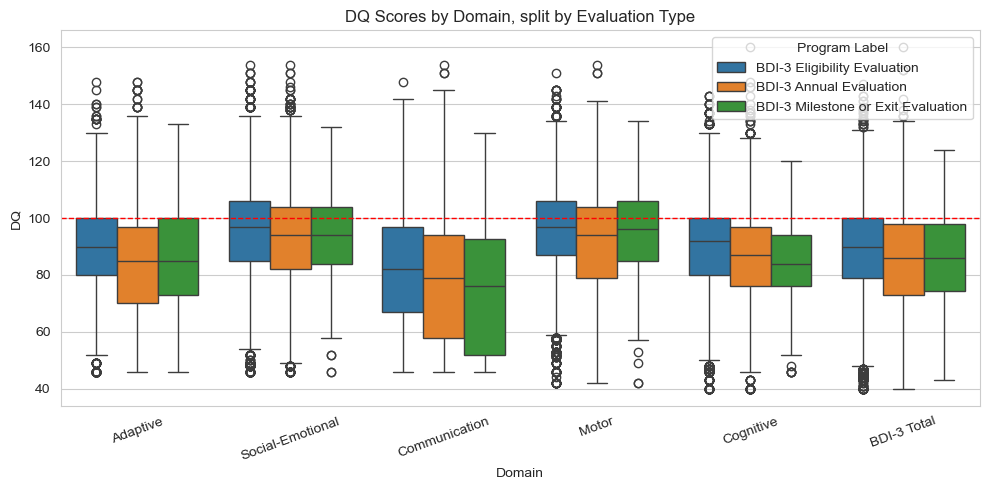

In [23]:
fig, ax = plt.subplots(figsize=(10,5))
plot_data = df.melt(id_vars='Program Label', value_vars=dq_domain_cols + ['BDI-3 Total Developmental Quotient'],
                     var_name='Domain', value_name='DQ')
plot_data['Domain'] = plot_data['Domain'].str.replace(' Developmental Quotient','')
sns.boxplot(data=plot_data, x='Domain', y='DQ', hue='Program Label', ax=ax)
ax.axhline(100, color='red', linestyle='--', linewidth=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.set_title('DQ Scores by Domain, split by Evaluation Type')
plt.tight_layout()
plt.show()


<a id="q7"></a>
## 9. Q7 — Is there a notable pattern of scoring by region?

In [24]:
region_summary = df.groupby('Region')[dq_domain_cols + ['BDI-3 Total Developmental Quotient']].agg(['mean','count'])
region_summary


Adaptive Developmental Quotient  \
                                                                              mean   
Region                                                                               
Region A (East TN / First TN / Southeast)                                86.490862   
Region B (Nashville / Upper Cumberland / South ...                       87.765814   
Region C (Northwest / Southwest / Memphis Delta)                         88.097484   

                                                          \
                                                   count   
Region                                                     
Region A (East TN / First TN / Southeast)           6621   
Region B (Nashville / Upper Cumberland / South ...  8015   
Region C (Northwest / Southwest / Memphis Delta)    4770   

                                                   Social-Emotional Developmental Quotient  \
                                                                                      mean   
Region                                                                                       
Region A (East TN / First TN / Southeast)                                        92.618594   
Region B (Nashville / Upper Cumberland / South ...                               94.109309   
Region C (Northwest / Southwest / Memphis Delta)                                 97.588679   

                                                          \
                                                   count   
Region                                                     
Region A (East TN / First TN / Southeast)           6615   
Region B (Nashville / Upper Cumberland / South ...  8014   
Region C (Northwest / Southwest / Memphis Delta)    4770   

                                                   Communication Developmental Quotient  \
                                                                                   mean   
Region                                                                                    
Region A (East TN / First TN / Southeast)                                     81.065961   
Region B (Nashville / Upper Cumberland / South ...                            78.835144   
Region C (Northwest / Southwest / Memphis Delta)                              78.970434   

                                                          \
                                                   count   
Region                                                     
Region A (East TN / First TN / Southeast)           6610   
Region B (Nashville / Upper Cumberland / South ...  8007   
Region C (Northwest / Southwest / Memphis Delta)    4769   

                                                   Motor Developmental Quotient  \
                                                                           mean   
Region                                                                            
Region A (East TN / First TN / Southeast)                             94.302691   
Region B (Nashville / Upper Cumberland / South ...                    93.876812   
Region C (Northwest / Southwest / Memphis Delta)                      95.957442   

                                                          \
                                                   count   
Region                                                     
Region A (East TN / First TN / Southeast)           6614   
Region B (Nashville / Upper Cumberland / South ...  8004   
Region C (Northwest / Southwest / Memphis Delta)    4770   

                                                   Cognitive Developmental Quotient  \
                                                                               mean   
Region                                                                                
Region A (East TN / First TN / Southeast)                                 89.986550   
Region B (Nashville / Upper Cumberland / South ...                        88.114343   
Region C (Northwest / Southwest / Memphis De

C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\2130188386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Region', y='DQ', ax=ax, palette='Set2')
C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\2130188386.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10)


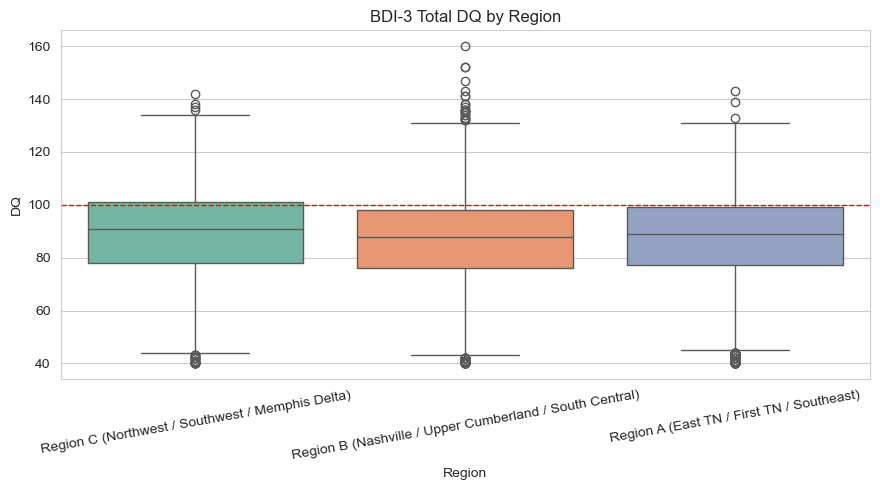

In [25]:
fig, ax = plt.subplots(figsize=(9,5))
plot_data = df.melt(id_vars='Region', value_vars=['BDI-3 Total Developmental Quotient'], var_name='Domain', value_name='DQ')
sns.boxplot(data=plot_data, x='Region', y='DQ', ax=ax, palette='Set2')
ax.axhline(100, color='red', linestyle='--', linewidth=1)
ax.set_title('BDI-3 Total DQ by Region')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
plt.tight_layout()
plt.show()


<a id="q8"></a>
## 10. Q8 — Is there a notable pattern of scoring by evaluator?

In [26]:
evaluator_counts = df['Evaluator'].value_counts()
print(f"Evaluators with at least 30 evaluations: {(evaluator_counts >= 30).sum()} of {len(evaluator_counts)} total")

active_evaluators = evaluator_counts[evaluator_counts >= 30].index
eval_df = df[df['Evaluator'].isin(active_evaluators)]

evaluator_summary = (eval_df.groupby('Evaluator')['BDI-3 Total Developmental Quotient']
                     .agg(['mean','std','count'])
                     .sort_values('mean'))
evaluator_summary


Evaluators with at least 30 evaluations: 88 of 105 total


,mean,std,count
Evaluator,,,
Tiffany Treadway,75.573248,21.448568,157
Amy Callender,77.327273,19.447036,55
James Brown,78.013889,15.593256,288
Laurie Brown,78.032000,15.874475,250
Dia Mimms,78.065359,15.925718,306
...,...,...,...
Ariauna Buckingham,95.775510,17.452633,49
Emily Williams,96.021277,16.508893,376
Melinda Morris,96.860377,20.894199,265


C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\2712675527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, y='Evaluator', x='BDI-3 Total Developmental Quotient', order=order, ax=ax, palette='coolwarm')


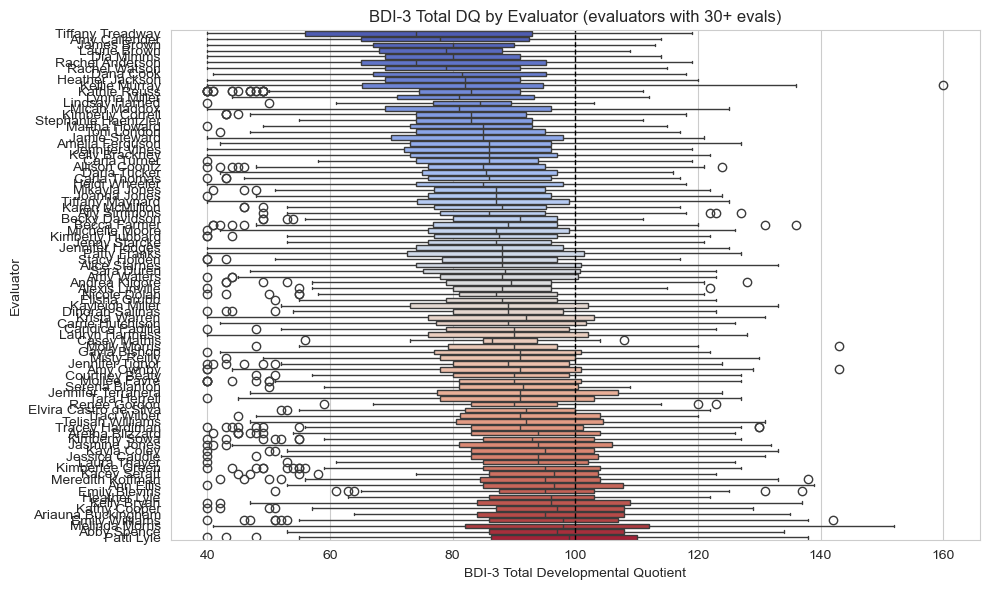

In [27]:
fig, ax = plt.subplots(figsize=(10,6))
order = evaluator_summary.index
sns.boxplot(data=eval_df, y='Evaluator', x='BDI-3 Total Developmental Quotient', order=order, ax=ax, palette='coolwarm')
ax.axvline(100, color='black', linestyle='--', linewidth=1)
ax.set_title('BDI-3 Total DQ by Evaluator (evaluators with 30+ evals)')
plt.tight_layout()
plt.show()


In [28]:
print("Evaluators with the lowest average Total DQ:")
print(evaluator_summary.head(5))
print("\nEvaluators with the highest average Total DQ:")
print(evaluator_summary.tail(5))


Evaluators with the lowest average Total DQ:
                       mean        std  count
Evaluator                                    
Tiffany Treadway  75.573248  21.448568    157
Amy Callender     77.327273  19.447036     55
James Brown       78.013889  15.593256    288
Laurie Brown      78.032000  15.874475    250
Dia Mimms         78.065359  15.925718    306

Evaluators with the highest average Total DQ:
                         mean        std  count
Evaluator                                      
Ariauna Buckingham  95.775510  17.452633     49
Emily Williams      96.021277  16.508893    376
Melinda Morris      96.860377  20.894199    265
Abby Spence         96.885093  16.096356    322
Patti Lyle          97.984211  18.079330    190


<a id="stretch1"></a>
## 11. Stretch Goal — Records missing a Child ID (SP####): better or worse over time?

C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\4263611629.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sp_over_time.index.astype(str), rotation=90)


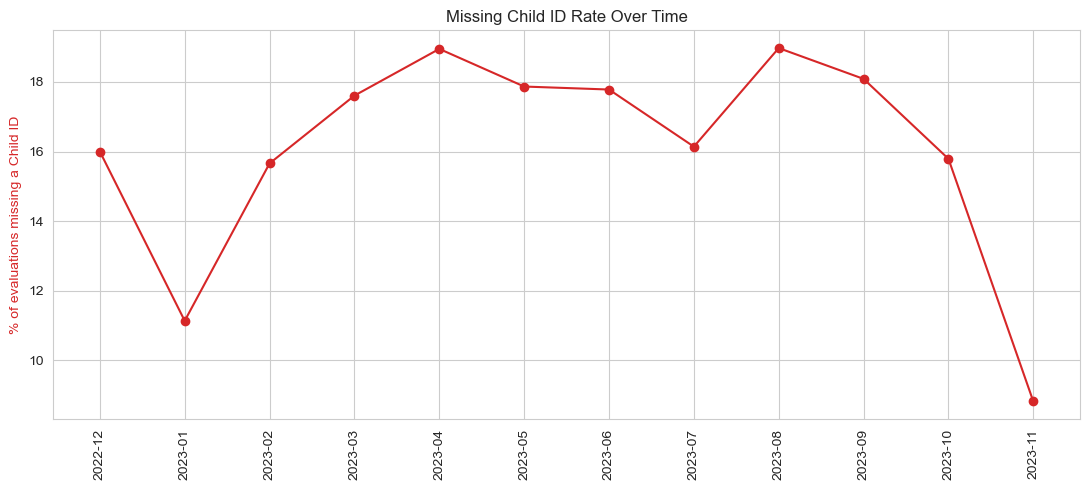

,% Missing ID,Count Missing,Total Evals
Month,,,
2022-12,0.160000,8,50
2023-01,0.111340,54,485
2023-02,0.156587,189,1207
2023-03,0.176071,337,1914
2023-04,0.189498,332,1752
2023-05,0.178681,409,2289
2023-06,0.177821,364,2047
2023-07,0.161404,322,1995
2023-08,0.189735,451,2377


In [29]:
sp_over_time = (df.assign(Month=df['Eval Date'].dt.to_period('M'))
                  .groupby('Month')['Missing_ID']
                  .agg(['mean','sum','count']))
sp_over_time.columns = ['% Missing ID', 'Count Missing', 'Total Evals']

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(sp_over_time.index.astype(str), sp_over_time['% Missing ID']*100, marker='o', color='tab:red')
ax1.set_ylabel('% of evaluations missing a Child ID', color='tab:red')
ax1.set_xticklabels(sp_over_time.index.astype(str), rotation=90)
ax1.set_title('Missing Child ID Rate Over Time')
plt.tight_layout()
plt.show()

sp_over_time.tail(12)


In [30]:
repeat_offenders = (df[df['Missing_ID']]
                    .groupby('Evaluator')
                    .size()
                    .sort_values(ascending=False)
                    .head(10))
print("Evaluators most frequently submitting evaluations with a missing Child ID:")
repeat_offenders


Evaluators most frequently submitting evaluations with a missing Child ID:


Evaluator
Kelly Brackney         421
Kimberly Hubbard       353
Mollee Favre           269
Melinda Morris         256
Kathie Reuss           253
Laurie Brown           249
Ann Ellis              176
Stephanie Haentzler    175
Andrea Kilgore         147
Heather Lyle           135
dtype: int64

<a id="stretch2"></a>
## 12. Stretch Goal — How often are children re-assessed less than 120 days apart, and has this changed over time?

Evaluation pairs less than 120 days apart: 140 out of 495 repeat-evaluation pairs (28.3%)


C:\Users\asiam\AppData\Local\Temp\ipykernel_4052\4139342111.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_gap_by_month.index.astype(str), rotation=90)


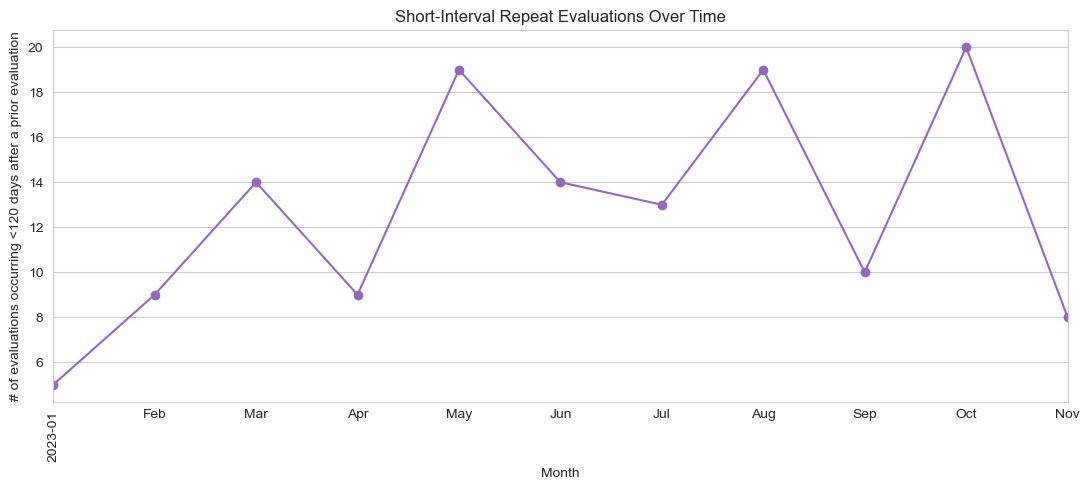

In [31]:
real_id = df[~df['Missing_ID']].sort_values(['Child ID', 'Eval Date'])
real_id['Days Since Prior Eval'] = real_id.groupby('Child ID')['Eval Date'].diff().dt.days

short_gap = real_id[real_id['Days Since Prior Eval'] < 120]
total_pairs = real_id['Days Since Prior Eval'].notna().sum()
print(f"Evaluation pairs less than 120 days apart: {len(short_gap):,} "
      f"out of {total_pairs:,} repeat-evaluation pairs "
      f"({len(short_gap) / total_pairs * 100:.1f}%)")

short_gap_by_month = (short_gap.assign(Month=short_gap['Eval Date'].dt.to_period('M'))
                      .groupby('Month').size())

fig, ax = plt.subplots(figsize=(11,5))
short_gap_by_month.plot(kind='line', marker='o', ax=ax, color='tab:purple')
ax.set_ylabel('# of evaluations occurring <120 days after a prior evaluation')
ax.set_title('Short-Interval Repeat Evaluations Over Time')
ax.set_xticklabels(short_gap_by_month.index.astype(str), rotation=90)
plt.tight_layout()
plt.show()
